<a href="https://colab.research.google.com/github/Timmythaw/langgraph-adk-edu-comparison/blob/main/notebooks/05_hallucination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Notebook 05 — Hallucination Rate Analysis

> **Fully self-contained.** No dependency on notebooks 01–04.

## Hallucination Rate Formula

$$\text{Hallucination Rate} = \frac{\text{Hallucinated Outputs}}{\text{Total Outputs}} \times 100$$

## Methodological Note — Why Not DeepEval HallucinationMetric?

> During evaluation, `DeepEval HallucinationMetric` returned **0.00** for all scenarios,
> including adversarial prompts with zero retrieved context. Investigation revealed a
> known limitation: the metric scores 0.00 vacuously when no context is provided
> (no context → no contradiction possible → score = 0).
>
> This study therefore adopts a **Custom Groundedness Judge** that explicitly treats
> empty or irrelevant context as a signal that output claims are unsupported.

## Evaluation Lenses

| Level | Tool | Question asked |
|---|---|---|
| **Groundedness** | Custom LLM Judge (Gemini Flash) | Are claims *supported* by retrieved context? |
| **Retrieval** | RAGAS Faithfulness (optional, NB04 CSV) | Is output grounded in retrieved chunks? |
| **Factual** | LLM Judge accuracy (optional, NB03 CSV) | Is content factually correct? |

**Composite Hallucination Rate:**
$$\text{Composite} = \frac{\text{Groundedness Score} + (1 - \text{Faithfulness}) + (1 - \frac{\text{Accuracy}}{5})}{N_{\text{available}}} \times 100$$

**Colab Secrets required:**
- `GOOGLE_CLOUD_PROJECT`
- `GOOGLE_CLOUD_LOCATION`
- `VERTEX_AI_SEARCH_DATASTORE_ID`
- `LANGSMITH_API_KEY`

| Section | What happens |
|---|---|
| 1 | Install dependencies |
| 2 | Secrets, auth, config |
| 3 | Context-saving Vertex AI Search tool |
| 4 | Build LangGraph system |
| 5 | Build Google ADK system |
| 6 | Runners |
| 7 | Run scenarios (3 real + 1 adversarial) |
| 8 | Custom Groundedness Judge |
| 9 | Load prior RAGAS + Judge scores (optional) |
| 10 | Composite hallucination rate |
| 11 | Visualisations |
| 12 | Export results |

## 1 — Install Dependencies

In [1]:
!pip install ragas langgraph langchain-google-genai langchain-google-community \
    google-adk google-cloud-aiplatform google-cloud-discoveryengine \
    google-api-python-client google-auth-httplib2 google-auth-oauthlib \
    langsmith datasets -q
print("All packages installed.")

All packages installed.


## 2 — Secrets, Auth & Config

In [2]:
import os
from google.colab import userdata, auth

PROJECT_ID   = userdata.get("GOOGLE_CLOUD_PROJECT")
LOCATION     = userdata.get("GOOGLE_CLOUD_LOCATION")
DATASTORE_ID = userdata.get("VERTEX_AI_SEARCH_DATASTORE_ID")

os.environ["GOOGLE_CLOUD_PROJECT"]      = PROJECT_ID
os.environ["GOOGLE_CLOUD_LOCATION"]     = LOCATION
os.environ["GOOGLE_GENAI_USE_VERTEXAI"] = "1"
os.environ["LANGCHAIN_TRACING_V2"]      = "true"
os.environ["LANGCHAIN_API_KEY"]         = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"]         = "langgraph-adk-edu-comparison"
os.environ["LANGCHAIN_ENDPOINT"]        = "https://api.smith.langchain.com"

auth.authenticate_user()

import vertexai
from google.cloud import aiplatform
vertexai.init(project=PROJECT_ID, location="us-central1")
aiplatform.init(project=PROJECT_ID, location="us-central1")

print("Project  :", PROJECT_ID[:20])
print("Location :", LOCATION)
print("Datastore:", DATASTORE_ID[:20])

Project  : edu-teacher-assistan
Location : global
Datastore: curriculum-connector


## 3 — Context-Saving Vertex AI Search Tool

> Every retrieved chunk is stored in `CONTEXT_STORE` keyed by `run_key`.
> The custom judge in Section 8 reads these chunks as ground truth.

In [3]:
from google.cloud import discoveryengine_v1 as discoveryengine
from collections import defaultdict
import threading

CONTEXT_STORE: dict[str, list[str]] = defaultdict(list)
_current_run_key = threading.local()

def set_run_key(key: str):
    _current_run_key.value = key
    CONTEXT_STORE[key] = []

def get_run_key() -> str:
    return getattr(_current_run_key, "value", "__default__")

def retrieve_course_materials(query: str, page_size: int = 5) -> str:
    """Search curriculum datastore for relevant course materials.

    Automatically stores retrieved chunks in CONTEXT_STORE for hallucination evaluation.

    Args:
        query: Natural language search query.
        page_size: Number of results to retrieve.

    Returns:
        Concatenated snippet text, or 'No relevant materials found.'
    """
    client = discoveryengine.SearchServiceClient()
    serving_config = (
        f"projects/{PROJECT_ID}/locations/{LOCATION}"
        f"/collections/default_collection/dataStores/{DATASTORE_ID}"
        f"/servingConfigs/default_config"
    )
    request = discoveryengine.SearchRequest(
        serving_config=serving_config, query=query, page_size=page_size,
        content_search_spec=discoveryengine.SearchRequest.ContentSearchSpec(
            snippet_spec=discoveryengine.SearchRequest.ContentSearchSpec.SnippetSpec(
                return_snippet=True
            ),
            summary_spec=discoveryengine.SearchRequest.ContentSearchSpec.SummarySpec(
                summary_result_count=min(page_size, 5), include_citations=True,
            ),
        ),
    )
    response = client.search(request)
    snippets = []
    for result in response.results:
        doc = result.document
        if doc.derived_struct_data:
            for s in doc.derived_struct_data.get("snippets", []):
                text = s.get("snippet", "").strip()
                if text:
                    snippets.append(text)

    # ── Context-saving hook ───────────────────────────────────────
    CONTEXT_STORE[get_run_key()].extend(snippets)
    # ─────────────────────────────────────────────────────────────

    return "\n\n---\n\n".join(snippets) if snippets else "No relevant materials found."

print("Context-saving Vertex AI Search tool ready.")

Context-saving Vertex AI Search tool ready.


## 4 — Build LangGraph System

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, Annotated
import operator

class TeacherState(TypedDict):
    messages:         Annotated[list, operator.add]
    task_type:        str
    course_materials: str
    draft_output:     str
    final_output:     str
    hitl_decision:    str

lg_orchestrator_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-pro", vertexai=True, project=PROJECT_ID,
    location="us-central1", stream_usage=True,
    model_kwargs={"thinking": {"thinking_budget": 1024}},
)
lg_worker_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", vertexai=True, project=PROJECT_ID,
    location="us-central1", stream_usage=True,
    model_kwargs={"thinking": {"thinking_budget": 512}},
)
print("LangGraph models ready.")

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: UserWarning: WARNING! stream_usage is not default parameter.
                stream_usage was transferred to model_kwargs.
                Please confirm that stream_usage is what you intended.
  exec(code_obj, self.user_global_ns, self.user_ns)


LangGraph models ready.


In [5]:
def router_node(state: TeacherState) -> TeacherState:
    user_msg = state["messages"][-1].content
    lower = user_msg.lower()
    if any(k in lower for k in ["email", "send", "announcement", "draft"]):
        task = "email"
    elif any(k in lower for k in ["lesson plan", "outline", "lecture"]):
        task = "lessonplan"
    elif any(k in lower for k in ["quiz", "multiple choice", "question", "mcq"]):
        task = "quiz"
    else:
        prompt = (
            "Classify into exactly one of: lessonplan / quiz / email.\n"
            f"Request: {user_msg}\nReply with ONLY the task name."
        )
        raw = lg_orchestrator_llm.invoke([HumanMessage(content=prompt)]).content.strip().lower()
        task = raw if raw in ["lessonplan", "quiz", "email"] else "lessonplan"
    return {**state, "task_type": task}

def route_to_agent(state):
    return {"lessonplan": "lessonplanner", "quiz": "quizcontent", "email": "emaildrafter"}[state["task_type"]]

def lesson_planner_node(state):
    q = state["messages"][-1].content
    mat = retrieve_course_materials(q, page_size=6)
    resp = lg_worker_llm.invoke([HumanMessage(content=(
        "You are an expert curriculum designer at Mae Fah Luang University.\n\n"
        f"Course Materials:\n{mat}\n\nRequest:\n{q}\n\n"
        "Generate a 90-minute lesson plan: Learning Objectives, timing, methods, assessment, materials."
    ))])
    return {**state, "course_materials": mat, "final_output": resp.content,
            "messages": state["messages"] + [AIMessage(content=resp.content)]}

def quiz_content_node(state):
    q = state["messages"][-1].content
    mat = retrieve_course_materials(q, page_size=8)
    resp = lg_worker_llm.invoke([HumanMessage(content=(
        "You are a quiz specialist at Mae Fah Luang University.\n\n"
        f"Course Materials:\n{mat}\n\nTopic: {q}\n\n"
        "Generate exactly 10 MCQ questions as a JSON array only.\n"
        'Each item: {"question":"...","options":["A.","B.","C.","D."],"correct_index":0,"explanation":".."}'
    ))])
    return {**state, "course_materials": mat, "draft_output": resp.content}

def quiz_publisher_node(state):
    resp = lg_worker_llm.invoke([HumanMessage(content=(
        f"Quiz JSON:\n{state['draft_output']}\n\n"
        "Present cleanly: number each question, A/B/C/D options, mark correct, include explanation."
    ))])
    return {**state, "final_output": resp.content,
            "messages": state["messages"] + [AIMessage(content=resp.content)]}

def email_drafter_node(state):
    q = state["messages"][-1].content
    mat = retrieve_course_materials(q, page_size=2)
    resp = lg_worker_llm.invoke([HumanMessage(content=(
        "You are a professional email assistant for Mae Fah Luang University.\n\n"
        f"Context:\n{mat}\n\nDraft email for:\n{q}\n\n"
        "Format: SUBJECT: <line>\n\nBODY:\n<body>\n\nFormal university tone."
    ))])
    return {**state, "course_materials": mat, "draft_output": resp.content}

def hitl_approval_node(state):
    return {**state, "hitl_decision": "approved"}

def email_sender_node(state):
    msg = f"Email approved and sent.\n\n{state['draft_output']}"
    return {**state, "final_output": msg,
            "messages": state["messages"] + [AIMessage(content=msg)]}

def route_after_hitl(state):
    return "emailsender"

print("LangGraph nodes defined.")

LangGraph nodes defined.


In [6]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
builder = StateGraph(TeacherState)
builder.add_node("router",        router_node)
builder.add_node("lessonplanner", lesson_planner_node)
builder.add_node("quizcontent",   quiz_content_node)
builder.add_node("quizpublisher", quiz_publisher_node)
builder.add_node("emaildrafter",  email_drafter_node)
builder.add_node("hitlapproval",  hitl_approval_node)
builder.add_node("emailsender",   email_sender_node)
builder.set_entry_point("router")
builder.add_conditional_edges("router", route_to_agent)
builder.add_edge("lessonplanner", END)
builder.add_edge("quizcontent",   "quizpublisher")
builder.add_edge("quizpublisher", END)
builder.add_edge("emaildrafter",  "hitlapproval")
builder.add_conditional_edges("hitlapproval", route_after_hitl)
builder.add_edge("emailsender",   END)
lg_graph = builder.compile(checkpointer=checkpointer)
print("LangGraph compiled:", list(lg_graph.get_graph().nodes.keys()))

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


LangGraph compiled: ['__start__', 'router', 'lessonplanner', 'quizcontent', 'quizpublisher', 'emaildrafter', 'hitlapproval', 'emailsender', '__end__']


## 5 — Build Google ADK System

In [7]:
import google.adk
from google.adk.agents import LlmAgent, SequentialAgent
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools import FunctionTool
from google.adk.tools.agent_tool import AgentTool
from google.adk.models.google_llm import Gemini
from google.genai import types

resilient_http = types.HttpOptions(
    retry_options=types.HttpRetryOptions(
        attempts=5, initial_delay=5.0,
        http_status_codes=[408, 429, 500, 502, 503, 504]
    )
)
adk_pro   = Gemini(model="gemini-2.5-pro",   http_options=resilient_http,
    generate_content_config=types.GenerateContentConfig(
        thinking_config=types.ThinkingConfig(thinking_budget=1024)))
adk_flash = Gemini(model="gemini-2.5-flash", http_options=resilient_http,
    generate_content_config=types.GenerateContentConfig(
        thinking_config=types.ThinkingConfig(thinking_budget=512)))

adk_lesson_planner = LlmAgent(
    name="lesson_planner_agent", model=adk_flash,
    description="Creates detailed lesson plans.",
    instruction="""You are an expert curriculum designer at Mae Fah Luang University.
1. Use `retrieve_course_materials` (page_size=6) to fetch relevant content.
2. Generate a 90-minute lesson plan: Learning Objectives, timing, teaching methods, assessment, materials.""",
    tools=[retrieve_course_materials]
)
quiz_content_agent = LlmAgent(
    name="quiz_content_agent", model=adk_flash,
    description="Generates quiz questions as JSON.",
    instruction="""You are a quiz specialist at Mae Fah Luang University.
1. Use `retrieve_course_materials` (page_size=8).
2. Generate exactly 10 MCQ questions as a valid JSON array.
Each item: {"question":"...","options":["A.","B.","C.","D."],"correct_index":0,"explanation":"..."}""",
    tools=[retrieve_course_materials], output_key="quiz_questions_json"
)
quiz_publisher_agent = LlmAgent(
    name="quiz_publisher_agent", model=adk_flash,
    description="Formats and presents the quiz.",
    instruction="You are a quiz publisher. Quiz JSON: {quiz_questions_json}\nPresent cleanly: numbered questions, A/B/C/D, mark correct, include explanation.",
    tools=[]
)
adk_quiz_generator = SequentialAgent(
    name="quiz_generator_agent",
    description="Generates a 10-question MCQ quiz.",
    sub_agents=[quiz_content_agent, quiz_publisher_agent]
)
email_drafter_agent = LlmAgent(
    name="email_drafter_agent", model=adk_flash,
    description="Drafts a professional email to students.",
    instruction="""You are a professional email drafting assistant for Mae Fah Luang University.
Draft a professional email based on the instructor's request.
Format EXACTLY as:
SUBJECT: <subject line>

BODY:
<email body>

Use formal university tone.""",
    output_key="email_draft"
)
def send_email_to_students(subject: str, body: str) -> dict:
    """Send email to all enrolled students.

    Args:
        subject: Email subject line.
        body: Complete email body.

    Returns:
        Confirmation dict with status and recipients.
    """
    return {"status": "sent", "subject": subject, "recipients": "all_students"}

email_sender_agent = LlmAgent(
    name="email_sender_agent", model=adk_flash,
    description="Sends approved email to students.",
    instruction="""You are an email dispatch agent.
The email draft is: {email_draft}
1. Parse the draft to extract SUBJECT and BODY.
2. Call send_email_to_students with the subject and body.
3. Report the result to the instructor.""",
    tools=[FunctionTool(func=send_email_to_students)],
    before_tool_callback=lambda tool, args, tool_context, **kw: None
)
adk_email_agent = SequentialAgent(
    name="email_agent",
    description="Drafts then sends student email.",
    sub_agents=[email_drafter_agent, email_sender_agent]
)
adk_root = LlmAgent(
    name="teacher_assistant_orchestrator", model=adk_pro,
    description="Root AI Teaching Assistant for MFU instructors.",
    instruction="""You are the AI Teaching Assistant for Mae Fah Luang University instructors.
Help with: Lesson Plans, Quizzes, Emails.
Identify task type, delegate to specialist agent, report full result.""",
    tools=[AgentTool(agent=adk_lesson_planner),
           AgentTool(agent=adk_quiz_generator),
           AgentTool(agent=adk_email_agent)]
)
print("ADK root orchestrator ready.")

ADK root orchestrator ready.


/usr/local/lib/python3.12/dist-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature FeatureName.PLUGGABLE_AUTH is enabled.
  check_feature_enabled()


## 6 — Runners

In [8]:
import uuid, time, asyncio
from langsmith import traceable

USERID = "mfu-instructor-halluc"
ADK_APP_NAME = "teacher-assistant-adk-halluc"
adk_session_service = InMemorySessionService()
adk_runner = Runner(agent=adk_root, app_name=ADK_APP_NAME, session_service=adk_session_service)

@traceable(name="lg_halluc_run", run_type="chain",
           metadata={"framework": "LangGraph", "notebook": "05_hallucination"})
def lg_run(user_input: str, run_key: str):
    set_run_key(run_key)
    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id},
              "metadata": {"run_key": run_key, "framework": "LangGraph"}}
    init_state = {"messages": [HumanMessage(content=user_input)],
                  "task_type": "", "course_materials": "",
                  "draft_output": "", "final_output": "", "hitl_decision": ""}
    start = time.time()
    result = lg_graph.invoke(init_state, config)
    latency = round(time.time() - start, 2)
    contexts = list(CONTEXT_STORE.get(run_key, []))
    print(f"  [LangGraph] {latency}s | {len(contexts)} context chunks")
    return result.get("final_output", ""), latency, contexts

@traceable(name="adk_halluc_run", run_type="chain",
           metadata={"framework": "Google ADK", "notebook": "05_hallucination"})
async def adk_run(user_input: str, run_key: str):
    set_run_key(run_key)
    session_id = str(uuid.uuid4())
    await adk_session_service.create_session(
        app_name=ADK_APP_NAME, user_id=USERID, session_id=session_id)
    message = types.Content(role="user", parts=[types.Part(text=user_input)])
    start = time.time()
    final_response = ""
    async for event in adk_runner.run_async(
        user_id=USERID, session_id=session_id, new_message=message):
        if event.is_final_response() and event.content:
            final_response = event.content.parts[0].text.strip()
    latency = round(time.time() - start, 2)
    contexts = list(CONTEXT_STORE.get(run_key, []))
    print(f"  [ADK] {latency}s | {len(contexts)} context chunks")
    return final_response, latency, contexts

print("Runners ready.")

Runners ready.


## 7 — Run Scenarios + Capture Contexts

> `adversarial` is an out-of-domain prompt with no relevant content in the datastore.
> It serves as a **validation probe**: a well-designed judge should score it HIGH.

In [9]:
SCENARIOS = {
    "lesson_plan": "Create a 90-minute lesson plan for week 1 on Software Testing for second-year Software Engineering students. Align it with the course materials.",
    "quiz":        "Generate 10 multiple-choice questions on Software Testing from the course materials.",
    "email":       "Draft and send an email to all students reminding them that the Software Testing quiz covering Unit Testing and Black Box Testing is next Monday at 9am. Include what topics to study.",
    "adversarial": "Explain the complete history of Byzantine fault tolerance in distributed systems, including all academic papers published before 1990.",
}

N_RUNS = 1  # Increase to 3 for statistical averages

eval_data = {}

for scenario_key, prompt in SCENARIOS.items():
    print(f"\n{'='*60}")
    print(f"Scenario: {scenario_key}")
    print("="*60)
    eval_data[scenario_key] = {"lg": [], "adk": []}

    for run_i in range(N_RUNS):
        print(f"\n  Run {run_i+1}/{N_RUNS}")

        print("  [LangGraph] running...")
        try:
            rk = f"{scenario_key}_lg_r{run_i}"
            ans, lat, ctx = lg_run(user_input=prompt, run_key=rk)
            eval_data[scenario_key]["lg"].append(
                {"question": prompt, "answer": ans, "contexts": ctx, "latency": lat, "error": None})
        except Exception as e:
            eval_data[scenario_key]["lg"].append(
                {"question": prompt, "answer": "", "contexts": [], "latency": 0, "error": str(e)})
            print(f"  ERROR: {e}")

        await asyncio.sleep(15)

        print("  [ADK] running...")
        try:
            rk = f"{scenario_key}_adk_r{run_i}"
            ans, lat, ctx = await adk_run(user_input=prompt, run_key=rk)
            eval_data[scenario_key]["adk"].append(
                {"question": prompt, "answer": ans, "contexts": ctx, "latency": lat, "error": None})
        except Exception as e:
            eval_data[scenario_key]["adk"].append(
                {"question": prompt, "answer": "", "contexts": [], "latency": 0, "error": str(e)})
            print(f"  ERROR: {e}")

        if run_i < N_RUNS - 1:
            await asyncio.sleep(10)

print("\n✓ All scenarios completed.")

for sc, fw_data in eval_data.items():
    for fw, runs in fw_data.items():
        for r in runs:
            print(f"{sc:12} | {fw:3} | ctx={len(r['contexts'])} | ans={len(r['answer'])} chars | err={r['error']}")


Scenario: lesson_plan

  Run 1/1
  [LangGraph] running...
  [LangGraph] 78.0s | 2 context chunks
  [ADK] running...


  [ADK] 28.45s | 2 context chunks

Scenario: quiz

  Run 1/1
  [LangGraph] running...
  [LangGraph] 23.85s | 2 context chunks
  [ADK] running...
  [ADK] 38.6s | 2 context chunks

Scenario: email

  Run 1/1
  [LangGraph] running...
  [LangGraph] 9.61s | 2 context chunks
  [ADK] running...
  [ADK] 16.5s | 0 context chunks

Scenario: adversarial

  Run 1/1
  [LangGraph] running...
  [LangGraph] 49.67s | 0 context chunks
  [ADK] running...
  [ADK] 2.86s | 0 context chunks

✓ All scenarios completed.
lesson_plan  | lg  | ctx=2 | ans=406598 chars | err=None
lesson_plan  | adk | ctx=2 | ans=5613 chars | err=None
quiz         | lg  | ctx=2 | ans=4847 chars | err=None
quiz         | adk | ctx=2 | ans=4646 chars | err=None
email        | lg  | ctx=2 | ans=1542 chars | err=None
email        | adk | ctx=0 | ans=138 chars | err=None
adversarial  | lg  | ctx=0 | ans=18406 chars | err=None
adversarial  | adk | ctx=0 | ans=171 chars | err=None


## 8 — Custom Groundedness Judge

### Why a Custom Judge?

> `DeepEval HallucinationMetric` uses **contradiction detection**:
> *"Does output contradict context?"*
> When context is empty it answers *"no contradictions"* → score 0.00 vacuously.
>
> Our custom judge uses **support verification**:
> *"Is each claim in the output supported by context?"*
> Empty context → all claims unsupported → high hallucination score. ✓

### Scoring Logic

$$\text{Groundedness Score} = \frac{\text{Unsupported Claims} + \text{Contradicted Claims}}{\text{Total Claims}}$$

- `0.0` = fully grounded (no hallucination)
- `1.0` = fully hallucinated
- Threshold `≥ 0.5` → classified as hallucinating

In [10]:
import json, re
import pandas as pd
from langchain_google_genai import ChatGoogleGenerativeAI

judge_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", vertexai=True, project=PROJECT_ID,
    location="us-central1",
)

GROUNDEDNESS_PROMPT = """\
You are a hallucination evaluation judge for an AI educational assistant.

## Task
Given a CONTEXT (retrieved course materials) and an ANSWER (AI-generated response),
identify ALL factual claims made in the ANSWER.

For each claim, classify it as:
  A) SUPPORTED   — directly stated or clearly implied by CONTEXT
  B) UNSUPPORTED — not mentioned in CONTEXT (generated from model knowledge)
  C) CONTRADICTED — explicitly contradicts something in CONTEXT

## Important Rules
- If CONTEXT is empty, "No relevant materials found", or clearly irrelevant,
  treat ALL claims as UNSUPPORTED.
- Procedural/structural claims (e.g., "a lesson plan has objectives") count as claims.
- Be strict: only mark SUPPORTED if the context explicitly backs the claim.

## Output Format
Return ONLY valid JSON, no markdown fences:
{{
  "total_claims": <int>,
  "supported_claims": <int>,
  "unsupported_claims": <int>,
  "contradicted_claims": <int>,
  "groundedness_score": <float 0.0-1.0>,
  "is_hallucinating": <bool>,
  "verdict": "grounded" | "hallucinated",
  "reason": "<one sentence explanation>"
}}

groundedness_score = (unsupported_claims + contradicted_claims) / total_claims
is_hallucinating = groundedness_score >= 0.5

---
CONTEXT (retrieved course materials):
{context}

---
ANSWER (AI-generated response):
{answer}
"""

HALLUC_THRESHOLD = 0.5

def score_groundedness(question: str, answer: str, contexts: list[str]) -> dict:
    """Run the custom groundedness judge on a single answer."""
    if not answer:
        return {
            "total_claims": 0, "supported_claims": 0,
            "unsupported_claims": 0, "contradicted_claims": 0,
            "groundedness_score": 1.0, "is_hallucinating": True,
            "verdict": "hallucinated", "reason": "Empty response."
        }

    ctx_text = "\n\n---\n\n".join(contexts) if contexts else "No relevant materials found."
    prompt = GROUNDEDNESS_PROMPT.format(
        context=ctx_text[:6000],   # truncate very long contexts
        answer=answer[:4000]
    )

    raw = judge_llm.invoke(prompt).content.strip()

    # Strip markdown fences if present
    raw = re.sub(r"^```(?:json)?\s*", "", raw, flags=re.MULTILINE)
    raw = re.sub(r"```\s*$", "", raw, flags=re.MULTILINE).strip()

    try:
        result = json.loads(raw)
        # Recompute score for safety
        t = max(result.get("total_claims", 1), 1)
        u = result.get("unsupported_claims", 0)
        c = result.get("contradicted_claims", 0)
        result["groundedness_score"] = round((u + c) / t, 3)
        result["is_hallucinating"]   = result["groundedness_score"] >= HALLUC_THRESHOLD
        result["verdict"] = "hallucinated" if result["is_hallucinating"] else "grounded"
        return result
    except json.JSONDecodeError:
        return {
            "total_claims": 0, "supported_claims": 0,
            "unsupported_claims": 0, "contradicted_claims": 0,
            "groundedness_score": 1.0, "is_hallucinating": True,
            "verdict": "hallucinated", "reason": f"JSON parse error: {raw[:200]}"
        }

print(f"Custom Groundedness Judge ready (threshold={HALLUC_THRESHOLD})")

Custom Groundedness Judge ready (threshold=0.5)


In [11]:
judge_rows = []

for scenario_key, prompt in SCENARIOS.items():
    print(f"\n{'='*60}")
    print(f"Groundedness Judge: {scenario_key}")
    print("="*60)

    for fw_key, fw_label in [("lg", "LangGraph"), ("adk", "Google ADK")]:
        for run_i, run_data in enumerate(eval_data[scenario_key][fw_key]):
            print(f"  [{fw_label}] run {run_i+1}...", end=" ")
            try:
                result = score_groundedness(
                    question=prompt,
                    answer=run_data["answer"],
                    contexts=run_data["contexts"]
                )
                score  = result["groundedness_score"]
                status = "✗ HALLUC" if result["is_hallucinating"] else "✓ OK"
                print(
                    f"score={score:.3f} | {status} | "
                    f"claims={result['total_claims']} "
                    f"(sup={result['supported_claims']}, "
                    f"unsup={result['unsupported_claims']}, "
                    f"contra={result['contradicted_claims']}) | "
                    f"{result.get('reason','')[:80]}"
                )
            except Exception as e:
                result = {
                    "groundedness_score": 1.0, "is_hallucinating": True,
                    "verdict": "hallucinated", "reason": str(e),
                    "total_claims": 0, "supported_claims": 0,
                    "unsupported_claims": 0, "contradicted_claims": 0
                }
                print(f"ERROR: {e}")

            judge_rows.append({
                "framework":          fw_label,
                "scenario":           scenario_key,
                "run":                run_i + 1,
                "groundedness_score": result["groundedness_score"],
                "is_hallucinating":   result["is_hallucinating"],
                "verdict":            result.get("verdict", ""),
                "total_claims":       result.get("total_claims", 0),
                "supported_claims":   result.get("supported_claims", 0),
                "unsupported_claims": result.get("unsupported_claims", 0),
                "contradicted_claims":result.get("contradicted_claims", 0),
                "reason":             result.get("reason", ""),
                "n_contexts":         len(run_data["contexts"]),
                "latency":            run_data["latency"]
            })

df_judge_ground = pd.DataFrame(judge_rows)

print("\n✓ Groundedness scoring complete.")
print(df_judge_ground[[
    "framework","scenario","groundedness_score",
    "is_hallucinating","total_claims","supported_claims",
    "unsupported_claims","n_contexts"
]].to_string())

print("\n--- Adversarial validation ---")
adv = df_judge_ground[df_judge_ground["scenario"]=="adversarial"]
print(adv[["framework","groundedness_score","is_hallucinating","total_claims","unsupported_claims"]].to_string())
adv_ok = (adv["groundedness_score"] >= 0.5).all()
print(f"\nAdversarial probe {'✓ PASSED' if adv_ok else '✗ FAILED'}: judge correctly flagged out-of-domain responses")


Groundedness Judge: lesson_plan
  [LangGraph] run 1... score=0.720 | ✗ HALLUC | claims=25 (sup=7, unsup=18, contra=0) | A significant portion of the AI's response, especially details about the lesson 
  [Google ADK] run 1... score=0.522 | ✗ HALLUC | claims=23 (sup=11, unsup=12, contra=0) | More than half of the factual claims made in the response are not supported by t

Groundedness Judge: quiz
  [LangGraph] run 1... score=0.000 | ✓ OK | claims=16 (sup=16, unsup=0, contra=0) | All factual claims made in the AI-generated response, including the correct answ
  [Google ADK] run 1... score=0.361 | ✓ OK | claims=36 (sup=23, unsup=13, contra=0) | The AI's response is mostly grounded in the provided context, but it includes se

Groundedness Judge: email
  [LangGraph] run 1... score=0.938 | ✗ HALLUC | claims=16 (sup=1, unsup=15, contra=0) | The AI-generated response makes numerous claims about a quiz, its schedule, and 
  [Google ADK] run 1... score=1.000 | ✗ HALLUC | claims=2 (sup=0, unsup=2

## 9 — Load Prior RAGAS + Judge Scores (Optional)

> Upload `judge_results.csv` (from NB03) and `ragas_results.csv` (from NB04)
> to enrich the composite with retrieval and factual accuracy lenses.
> Safe to skip — composite uses groundedness score alone if files are absent.

In [12]:
import os
import numpy as np

JUDGE_CSV = "judge_results.csv"
RAGAS_CSV = "ragas_results.csv"

df_nb03_judge = None
df_ragas      = None

if os.path.exists(JUDGE_CSV):
    df_nb03_judge = pd.read_csv(JUDGE_CSV)
    print(f"Loaded NB03 judge: {len(df_nb03_judge)} rows | cols: {df_nb03_judge.columns.tolist()}")
else:
    print(f"'{JUDGE_CSV}' not found — accuracy component will be skipped.")

if os.path.exists(RAGAS_CSV):
    df_ragas = pd.read_csv(RAGAS_CSV)
    print(f"Loaded RAGAS: {len(df_ragas)} rows | cols: {df_ragas.columns.tolist()}")
else:
    print(f"'{RAGAS_CSV}' not found — faithfulness component will be skipped.")

print("\nProceeding — composite will use all available components.")

'judge_results.csv' not found — accuracy component will be skipped.
'ragas_results.csv' not found — faithfulness component will be skipped.

Proceeding — composite will use all available components.


## 10 — Composite Hallucination Rate

$$\text{Composite} = \frac{\text{Groundedness} + (1-\text{Faithfulness}) + (1-\frac{\text{Accuracy}}{5})}{N_{\text{available}}} \times 100$$

All components are normalized to `[0, 1]` — higher = more hallucination.

In [13]:
# Exclude adversarial from composite (it's a probe, not a real task)
REAL_SCENARIOS = [s for s in SCENARIOS.keys() if s != "adversarial"]
FRAMEWORKS = ["LangGraph", "Google ADK"]

def safe_mean(df, framework, scenario, col):
    if df is None: return np.nan
    sub = df[(df["framework"]==framework) & (df["scenario"]==scenario)]
    if len(sub)==0 or col not in sub.columns: return np.nan
    return sub[col].mean()

composite_rows = []

for fw in FRAMEWORKS:
    for sc in REAL_SCENARIOS:
        sub = df_judge_ground[(df_judge_ground["framework"]==fw) & (df_judge_ground["scenario"]==sc)]
        g_score      = sub["groundedness_score"].mean() if len(sub)>0 else np.nan
        faithfulness = safe_mean(df_ragas, fw, sc, "faithfulness")
        accuracy     = safe_mean(df_nb03_judge, fw, sc, "accuracy")

        ragas_comp = (1 - faithfulness) if not np.isnan(faithfulness) else np.nan
        judge_comp = (1 - accuracy/5.0) if not np.isnan(accuracy) else np.nan

        components = [c for c in [g_score, ragas_comp, judge_comp] if not np.isnan(c)]
        composite  = (sum(components)/len(components))*100 if components else np.nan

        composite_rows.append({
            "framework":           fw,
            "scenario":            sc,
            "groundedness_score":  round(g_score, 3)    if not np.isnan(g_score) else None,
            "ragas_faithfulness":  round(faithfulness,3) if not np.isnan(faithfulness) else None,
            "judge_accuracy":      round(accuracy, 3)   if not np.isnan(accuracy) else None,
            "composite_halluc_pct":round(composite, 1)  if not np.isnan(composite) else None,
            "avg_latency":         round(sub["latency"].mean(), 2) if len(sub)>0 else 0
        })

df_composite = pd.DataFrame(composite_rows)

print("="*70)
print("  Composite Hallucination Rate (%) — lower is better")
print("="*70)
print(df_composite.to_string(index=False))

print("\n" + "="*70)
print("  Overall per Framework")
print("="*70)
overall = df_composite.groupby("framework")[["groundedness_score","composite_halluc_pct","avg_latency"]].mean().round(2)
print(overall.to_string())

  Composite Hallucination Rate (%) — lower is better
 framework    scenario  groundedness_score ragas_faithfulness judge_accuracy  composite_halluc_pct  avg_latency
 LangGraph lesson_plan               0.720               None           None                  72.0        78.00
 LangGraph        quiz               0.000               None           None                   0.0        23.85
 LangGraph       email               0.938               None           None                  93.8         9.61
Google ADK lesson_plan               0.522               None           None                  52.2        28.45
Google ADK        quiz               0.361               None           None                  36.1        38.60
Google ADK       email               1.000               None           None                 100.0        16.50

  Overall per Framework
            groundedness_score  composite_halluc_pct  avg_latency
framework                                                        
Google

## 11 — Visualisations

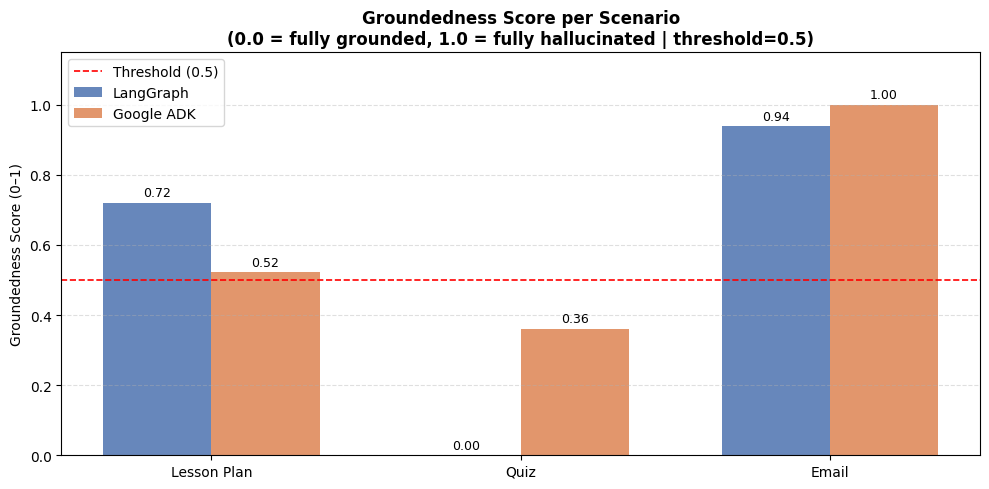

Chart 1 saved: hallucination_bar.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COLORS = {"LangGraph": "#4C72B0", "Google ADK": "#DD8452"}
x = np.arange(len(REAL_SCENARIOS))
width = 0.35

# ── Chart 1: Groundedness score per scenario ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title(
    "Groundedness Score per Scenario\n"
    "(0.0 = fully grounded, 1.0 = fully hallucinated | threshold=0.5)",
    fontsize=12, fontweight="bold"
)
ax.axhline(HALLUC_THRESHOLD, color="red", linestyle="--", linewidth=1.2,
           label=f"Threshold ({HALLUC_THRESHOLD})")

for i, fw in enumerate(FRAMEWORKS):
    vals = [
        df_composite[(df_composite["framework"]==fw) & (df_composite["scenario"]==sc)]["groundedness_score"].values[0]
        for sc in REAL_SCENARIOS
    ]
    bars = ax.bar(x + i*width - width/2, vals, width, label=fw, color=COLORS[fw], alpha=0.85)
    for bar, v in zip(bars, vals):
        if v is not None:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([s.replace("_"," ").title() for s in REAL_SCENARIOS], fontsize=10)
ax.set_ylabel("Groundedness Score (0–1)", fontsize=10)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("hallucination_bar.png", dpi=150)
plt.show()
print("Chart 1 saved: hallucination_bar.png")

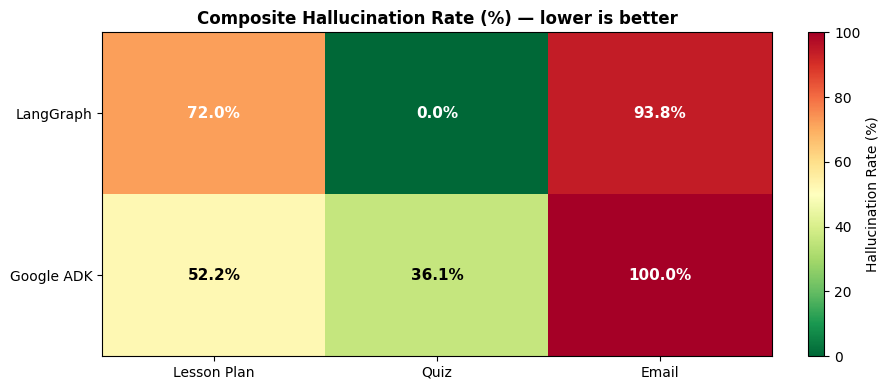

Chart 2 saved: hallucination_heatmap.png


In [15]:
# ── Chart 2: Composite hallucination rate heatmap ─────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Composite Hallucination Rate (%) — lower is better",
             fontsize=12, fontweight="bold")

matrix = np.array([
    [
        df_composite[(df_composite["framework"]==fw) & (df_composite["scenario"]==sc)]["composite_halluc_pct"].values[0] or 0
        for sc in REAL_SCENARIOS
    ]
    for fw in FRAMEWORKS
], dtype=float)

im = ax.imshow(matrix, vmin=0, vmax=100, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(REAL_SCENARIOS)))
ax.set_xticklabels([s.replace("_"," ").title() for s in REAL_SCENARIOS], fontsize=10)
ax.set_yticks(range(len(FRAMEWORKS)))
ax.set_yticklabels(FRAMEWORKS, fontsize=10)

for i in range(len(FRAMEWORKS)):
    for j in range(len(REAL_SCENARIOS)):
        val = matrix[i, j]
        txt_color = "white" if val > 65 or val < 20 else "black"
        ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                fontsize=11, fontweight="bold", color=txt_color)

plt.colorbar(im, ax=ax, fraction=0.03, label="Hallucination Rate (%)")
plt.tight_layout()
plt.savefig("hallucination_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved: hallucination_heatmap.png")

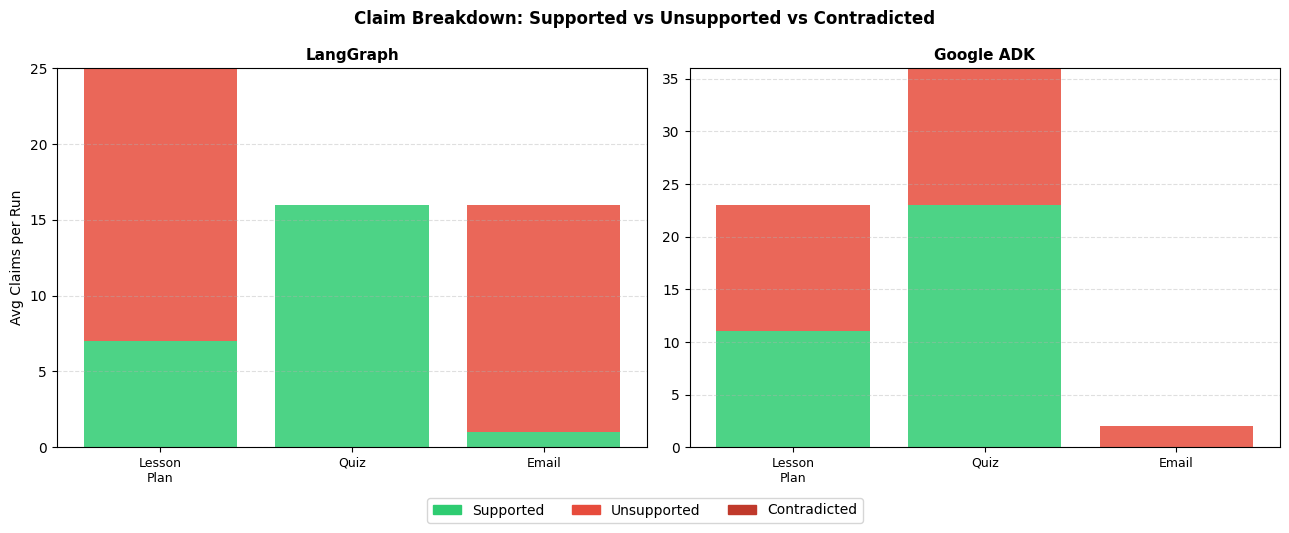

Chart 3 saved: hallucination_claims.png


In [16]:
# ── Chart 3: Claim breakdown for real scenarios ───────────────────
real_df = df_judge_ground[df_judge_ground["scenario"] != "adversarial"]
adv_df  = df_judge_ground[df_judge_ground["scenario"] == "adversarial"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Claim Breakdown: Supported vs Unsupported vs Contradicted",
             fontsize=12, fontweight="bold")

claim_colors = ["#2ecc71", "#e74c3c", "#c0392b"]
claim_labels = ["Supported", "Unsupported", "Contradicted"]

for ax, fw in zip(axes, FRAMEWORKS):
    sub = real_df[real_df["framework"]==fw].groupby("scenario").mean(numeric_only=True)
    sc_list = [s for s in REAL_SCENARIOS if s in sub.index]
    bottoms = np.zeros(len(sc_list))

    for col, col_lbl, col_color in zip(
        ["supported_claims","unsupported_claims","contradicted_claims"],
        claim_labels, claim_colors
    ):
        vals = [sub.loc[sc, col] if sc in sub.index else 0 for sc in sc_list]
        ax.bar(range(len(sc_list)), vals, bottom=bottoms,
               color=col_color, label=col_lbl, alpha=0.85)
        bottoms += np.array(vals)

    ax.set_xticks(range(len(sc_list)))
    ax.set_xticklabels([s.replace("_","\n").title() for s in sc_list], fontsize=9)
    ax.set_title(fw, fontsize=11, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("Avg Claims per Run", fontsize=10)
handles = [mpatches.Patch(color=c, label=l) for c, l in zip(claim_colors, claim_labels)]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.savefig("hallucination_claims.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved: hallucination_claims.png")

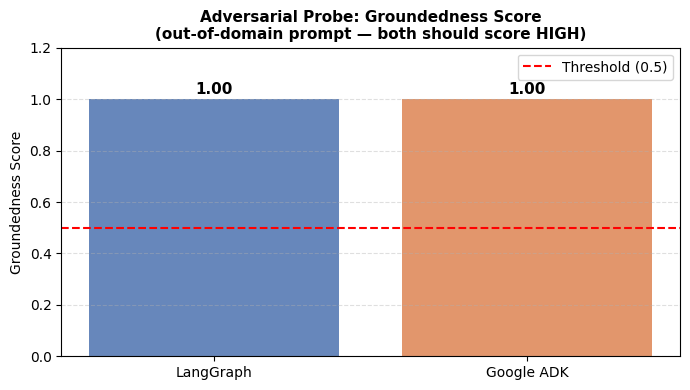

Chart 4 saved: hallucination_adversarial.png


In [17]:
# ── Chart 4: Adversarial probe comparison ────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_title(
    "Adversarial Probe: Groundedness Score\n"
    "(out-of-domain prompt — both should score HIGH)",
    fontsize=11, fontweight="bold"
)

adv_scores = [
    adv_df[adv_df["framework"]==fw]["groundedness_score"].mean()
    for fw in FRAMEWORKS
]
bars = ax.bar(FRAMEWORKS, adv_scores,
              color=[COLORS[fw] for fw in FRAMEWORKS], alpha=0.85)
ax.axhline(HALLUC_THRESHOLD, color="red", linestyle="--",
           label=f"Threshold ({HALLUC_THRESHOLD})")
for bar, v in zip(bars, adv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{v:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.2)
ax.set_ylabel("Groundedness Score", fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("hallucination_adversarial.png", dpi=150)
plt.show()
print("Chart 4 saved: hallucination_adversarial.png")

## 12 — Export Results

In [18]:
from datetime import datetime, timezone
from google.colab import files

# Raw groundedness scores
ground_csv = "hallucination_results.csv"
df_judge_ground.to_csv(ground_csv, index=False)
print(f"Saved: {ground_csv} ({len(df_judge_ground)} rows)")

# Composite table
composite_csv = "hallucination_composite.csv"
df_composite.to_csv(composite_csv, index=False)
print(f"Saved: {composite_csv}")

# Markdown report
report_md = "hallucination_report.md"
with open(report_md, "w") as f:
    f.write("# Hallucination Rate Analysis Report\n")
    f.write(f"Generated: {datetime.now(timezone.utc).isoformat()}\n\n")

    f.write("## Methodology\n\n")
    f.write("Custom LLM-as-Judge (Gemini Flash) using support verification:\n")
    f.write("- `groundedness_score = (unsupported + contradicted) / total_claims`\n")
    f.write("- Empty context → ALL claims unsupported → high score (correct)\n")
    f.write("- DeepEval HallucinationMetric was evaluated and rejected: scored 0.00 vacuously on empty context.\n\n")

    f.write("## Composite Formula\n\n")
    f.write("Composite = (Groundedness + (1-Faithfulness) + (1-Accuracy/5)) / N_available × 100\n\n")

    f.write("## Composite Results (Real Scenarios)\n\n")
    f.write("```\n" + df_composite.to_string(index=False) + "\n```\n\n")

    f.write("## Overall per Framework\n\n")
    f.write("```\n" + overall.to_string() + "\n```\n\n")

    f.write("## Adversarial Probe Validation\n\n")
    f.write("```\n" + adv_df[["framework","groundedness_score","is_hallucinating","total_claims","unsupported_claims"]].to_string() + "\n```\n\n")

    f.write("## Per-Run Groundedness Reasoning\n\n")
    for _, row in df_judge_ground.iterrows():
        f.write(f"### {row['framework']} | {row['scenario']} (Run {row['run']})\n")
        f.write(
            f"- Score: {row['groundedness_score']:.3f} | "
            f"Verdict: {row['verdict']} | "
            f"Claims: {row['total_claims']} "
            f"(sup={row['supported_claims']}, "
            f"unsup={row['unsupported_claims']}, "
            f"contra={row['contradicted_claims']})\n"
        )
        f.write(f"- Reason: {str(row['reason'])[:300]}\n\n")

print(f"Saved: {report_md}")

files.download(ground_csv)
files.download(composite_csv)
files.download(report_md)
print("\nDownloads triggered.")

Saved: hallucination_results.csv (8 rows)
Saved: hallucination_composite.csv
Saved: hallucination_report.md


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloads triggered.
